In [ ]:
# lollipop plot

[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_lollipop_probability_AUGUST.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_lollipop_probability_AUGUST.jpg


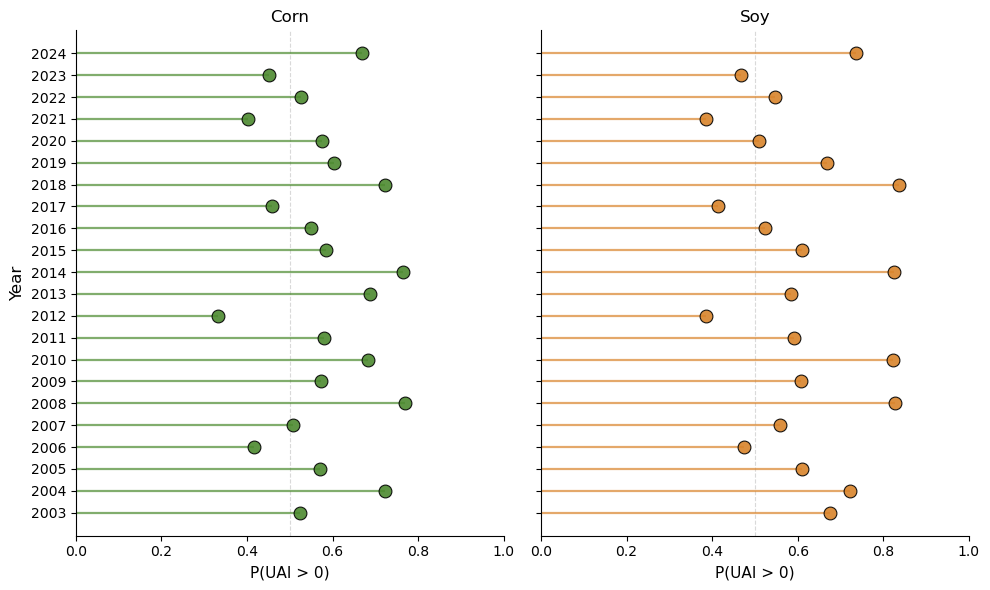

In [3]:
#!/usr/bin/env python3
# uai_lollipop_probability_august.py
#
# Horizontal lollipop plots of the probability that historical wetlands
# underperform adjacent uplands in August (P[UAI > 0]).
#
# UAI = mean(EVI2 upland) − mean(EVI2 wetland)
#
# Two panels:
#   - Left: corn
#   - Right: soy
#
# Input:
#   UAI_prepped_AUGUST.csv (cached August UAI data, one row per wetland)
#
# Output:
#   Figure_UAI_lollipop_probability_AUGUST.png / .jpg
#
# Author: Kimberly Van Meter

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

# Where the cached UAI data and figures live
OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Cached August UAI CSV produced by earlier scripts
CACHE_CSV = OUT_ROOT / "UAI_prepped_AUGUST.csv"

# Output figure paths
OUT_PNG = OUT_ROOT / "Figure_UAI_lollipop_probability_AUGUST.png"
OUT_JPG = OUT_ROOT / "Figure_UAI_lollipop_probability_AUGUST.jpg"

# Crops and colors
CROPS = ["corn", "soy"]       # left panel: corn; right panel: soy
COLORS = {
    "corn": "#4C8A2F",        # green-ish, consistent with other figures
    "soy":  "#D9842B",        # orange (matches your histogram soy color)
}

# Plot aesthetics
FIGSIZE       = (10, 6)
MARKER_SIZE   = 85
STEM_WIDTH    = 1.6
ALPHA_MARKER  = 0.9
ALPHA_STEM    = 0.7

# Minimum number of wetlands per crop-year to compute probability
MIN_N_PER_YEAR = 10


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def compute_probability_uai_positive(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute probability(UAI > 0) for each year × crop.

    Returns a tidy DataFrame with columns:
        year, crop, prob, n
    where:
        prob = fraction of wetlands with UAI > 0
        n    = number of wetlands used for that year × crop
    """
    out_rows = []

    # Ensure types
    df = df.copy()
    df["year"] = df["year"].astype(int)
    df["crop"] = df["crop"].astype(str)

    for crop in CROPS:
        dfc = df[df["crop"] == crop]
        years = sorted(dfc["year"].unique())

        for yr in years:
            subset = dfc[dfc["year"] == yr]["UAI"].dropna()
            n = subset.size
            if n < MIN_N_PER_YEAR:
                # Skip years with insufficient data
                continue

            prob = float(np.mean(subset > 0))
            out_rows.append(
                {
                    "year": yr,
                    "crop": crop,
                    "prob": prob,
                    "n": n,
                }
            )

    if not out_rows:
        raise ValueError("No crop–year combinations with sufficient data to compute probabilities.")

    return pd.DataFrame(out_rows)


def plot_lollipop(df_prob: pd.DataFrame) -> None:
    """
    Horizontal lollipop plot:

      - Left panel: corn
      - Right panel: soy

    For each crop × year, show probability(UAI > 0). Years are labeled
    on the y-axis for both panels.

    df_prob must have columns: year, crop, prob.
    """

    # Make sure we have the crops we expect
    df_prob = df_prob.copy()
    df_prob["crop"] = df_prob["crop"].astype(str)
    df_prob["year"] = df_prob["year"].astype(int)

    crops = CROPS
    n_crops = len(crops)

    # Determine full set of years across both crops (for shared y-axis)
    all_years = sorted(df_prob["year"].unique())
    y_positions = np.arange(len(all_years))

    fig, axes = plt.subplots(1, n_crops, figsize=FIGSIZE, sharey=True)

    if n_crops == 1:
        axes = [axes]

    for j, crop in enumerate(crops):
        ax = axes[j]

        # Slice to this crop, but reindex to all years so we get consistent y positions
        dfc = df_prob[df_prob["crop"] == crop].set_index("year").reindex(all_years)
        probs = dfc["prob"].values

        # Some years may be NaN (no data for this crop-year); handle gracefully
        # Stems: only where prob is finite
        valid_mask = np.isfinite(probs)

        # Draw stems
        ax.hlines(
            y=y_positions[valid_mask],
            xmin=0,
            xmax=probs[valid_mask],
            color=COLORS.get(crop, "gray"),
            alpha=ALPHA_STEM,
            linewidth=STEM_WIDTH,
        )

        # Draw markers
        ax.scatter(
            probs[valid_mask],
            y_positions[valid_mask],
            s=MARKER_SIZE,
            color=COLORS.get(crop, "gray"),
            edgecolor="black",
            linewidth=0.8,
            alpha=ALPHA_MARKER,
            zorder=3,
        )

        # Axes formatting
        ax.set_title(crop.capitalize(), fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_xlabel("P(UAI > 0)", fontsize=11)

        # Label years on BOTH panels
        ax.set_yticks(y_positions)
        ax.set_yticklabels(all_years)

        # Earliest year at top
        ax.invert_yaxis()

        # Clean, journal-style look
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        # Optional: add light vertical reference lines (e.g., at 0.25, 0.5, 0.75)
        ax.axvline(0.5, color="0.85", linestyle="--", linewidth=0.8, zorder=0)

    # Y-axis label on left panel only (years appear on both)
    axes[0].set_ylabel("Year", fontsize=12)

    plt.tight_layout()
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # Load cached August UAI dataset
    if not CACHE_CSV.exists():
        raise FileNotFoundError(
            f"Cached UAI file not found: {CACHE_CSV}\n"
            "Make sure you have run the August UAI preparation script first."
        )

    df = pd.read_csv(CACHE_CSV)

    # Basic checks
    required_cols = {"year", "crop", "UAI"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Cached CSV is missing required columns: {missing}")

    # Compute probability(UAI > 0) by crop and year
    df_prob = compute_probability_uai_positive(df)

    # Plot lollipop figure
    plot_lollipop(df_prob)


if __name__ == "__main__":
    main()
